In [1]:
import pandas as pd
from pprint import PrettyPrinter
from pymongo import MongoClient
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/PRSA_data_2010.1.1-2014.12.31.csv")

## EDA before querying with PyMongo

In [3]:
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [5]:
df.isna().sum()

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

In [6]:
df[["year", "month", "day", "hour"]].head()

,year,month,day,hour
0,2010,1,1,0
1,2010,1,1,1
2,2010,1,1,2
3,2010,1,1,3
4,2010,1,1,4


In [7]:
df[["year", "month", "day", "hour"]].tail()

,year,month,day,hour
43819,2014,12,31,19
43820,2014,12,31,20
43821,2014,12,31,21
43822,2014,12,31,22
43823,2014,12,31,23


In [8]:
df["year"].value_counts().sort_index()

year
2010    8760
2011    8760
2012    8784
2013    8760
2014    8760
Name: count, dtype: int64

In [9]:
df["cbwd"].value_counts()

cbwd
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64

In [10]:
df["pm2.5"].describe()

count    41757.000000
mean        98.613215
std         92.050387
min          0.000000
25%         29.000000
50%         72.000000
75%        137.000000
max        994.000000
Name: pm2.5, dtype: float64

In [11]:
df["hour"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [12]:
df["month"].unique()


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [13]:
df["year"].unique()

array([2010, 2011, 2012, 2013, 2014])

In [14]:
df["day"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [15]:
df.groupby("month")["day"].max()

month
1     31
2     29
3     31
4     30
5     31
6     30
7     31
8     31
9     30
10    31
11    30
12    31
Name: day, dtype: int64

In [16]:
df["timestamp"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]]
)

In [17]:
df[["year", "month", "day", "hour", "timestamp"]].tail()

,year,month,day,hour,timestamp
43819,2014,12,31,19,2014-12-31 19:00:00
43820,2014,12,31,20,2014-12-31 20:00:00
43821,2014,12,31,21,2014-12-31 21:00:00
43822,2014,12,31,22,2014-12-31 22:00:00
43823,2014,12,31,23,2014-12-31 23:00:00


In [18]:
df["timestamp"].is_unique

True

In [19]:
df["timestamp"].dtype

dtype('<M8[ns]')

In [20]:
df["timestamp"].duplicated().sum()

np.int64(0)

In [21]:
df["timestamp"].diff().value_counts().head(10)

timestamp
0 days 01:00:00    43823
Name: count, dtype: int64

In [22]:
df["timestamp"].nunique()

43824

In [23]:
df = df.sort_values("timestamp").reset_index(drop=True)

In [24]:
df.tail(10)

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,timestamp
43814,43815,2014,12,31,14,9.0,-27,1.0,1032.0,NW,196.21,0,0,2014-12-31 14:00:00
43815,43816,2014,12,31,15,11.0,-26,1.0,1032.0,NW,205.15,0,0,2014-12-31 15:00:00
43816,43817,2014,12,31,16,8.0,-23,0.0,1032.0,NW,214.09,0,0,2014-12-31 16:00:00
43817,43818,2014,12,31,17,9.0,-22,-1.0,1033.0,NW,221.24,0,0,2014-12-31 17:00:00
43818,43819,2014,12,31,18,10.0,-22,-2.0,1033.0,NW,226.16,0,0,2014-12-31 18:00:00
43819,43820,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0,2014-12-31 19:00:00
43820,43821,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0,2014-12-31 20:00:00
43821,43822,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0,2014-12-31 21:00:00
43822,43823,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,0,0,2014-12-31 22:00:00
43823,43824,2014,12,31,23,12.0,-21,-3.0,1034.0,NW,249.85,0,0,2014-12-31 23:00:00


In [25]:
df[df["pm2.5"].isna()][["timestamp", "pm2.5"]].head(10)

,timestamp,pm2.5
0,2010-01-01 00:00:00,NaN
1,2010-01-01 01:00:00,NaN
2,2010-01-01 02:00:00,NaN
3,2010-01-01 03:00:00,NaN
4,2010-01-01 04:00:00,NaN
5,2010-01-01 05:00:00,NaN
6,2010-01-01 06:00:00,NaN
7,2010-01-01 07:00:00,NaN
8,2010-01-01 08:00:00,NaN
9,2010-01-01 09:00:00,NaN


In [26]:
df[df["pm2.5"].isna()][["timestamp", "pm2.5"]].tail(10)

,timestamp,pm2.5
43283,2014-12-09 11:00:00,NaN
43544,2014-12-20 08:00:00,NaN
43545,2014-12-20 09:00:00,NaN
43546,2014-12-20 10:00:00,NaN
43547,2014-12-20 11:00:00,NaN
43548,2014-12-20 12:00:00,NaN
43549,2014-12-20 13:00:00,NaN
43550,2014-12-20 14:00:00,NaN
43551,2014-12-20 15:00:00,NaN
43552,2014-12-20 16:00:00,NaN


In [27]:
missing = df["pm2.5"].isna()

In [28]:
groups = missing.ne(missing.shift()).cumsum()
groups

0          1
1          1
2          1
3          1
4          1
        ... 
43819    428
43820    428
43821    428
43822    428
43823    428
Name: pm2.5, Length: 43824, dtype: int64

In [29]:
missing_blocks = (
    df[missing]
    .groupby(groups[missing])
    .agg(
        start=("timestamp", "min"),
        end=("timestamp", "max"),
        count=("timestamp", "size")
    )
)

missing_blocks.head(20)

,start,end,count
pm2.5,,,
1,2010-01-01 00:00:00,2010-01-01 23:00:00,24
3,2010-01-23 17:00:00,2010-01-26 11:00:00,67
5,2010-02-14 02:00:00,2010-02-14 02:00:00,1
7,2010-03-20 05:00:00,2010-03-20 06:00:00,2
9,2010-03-22 23:00:00,2010-03-22 23:00:00,1
11,2010-03-30 06:00:00,2010-03-30 12:00:00,7
13,2010-03-30 14:00:00,2010-03-31 06:00:00,17
15,2010-03-31 09:00:00,2010-03-31 16:00:00,8
17,2010-04-01 11:00:00,2010-04-01 12:00:00,2


In [30]:
missing_blocks["count"].describe()

count    214.000000
mean       9.658879
std       21.413665
min        1.000000
25%        1.000000
50%        1.000000
75%        7.000000
max      155.000000
Name: count, dtype: float64

In [31]:
missing_blocks["count"].value_counts().sort_index()

count
1      112
2       29
3        2
4        5
5        6
6        4
7        6
8        3
9        6
10       3
11       1
12       2
14       2
16       2
17       2
19       2
20       1
22       2
23       1
24       3
29       2
37       1
40       1
42       1
44       1
48       1
52       1
54       1
63       1
67       1
68       1
72       1
74       2
76       1
91       1
99       1
127      1
155      1
Name: count, dtype: int64

In [32]:
missing_blocks.sort_values("count", ascending=False).head(10)

,start,end,count
pm2.5,,,
41,2010-09-21 05:00:00,2010-09-27 15:00:00,155
287,2012-12-23 06:00:00,2012-12-28 12:00:00,127
163,2011-10-03 13:00:00,2011-10-07 15:00:00,99
61,2011-03-17 21:00:00,2011-03-21 15:00:00,91
43,2010-09-27 17:00:00,2010-09-30 20:00:00,76
185,2012-01-14 10:00:00,2012-01-17 11:00:00,74
259,2012-08-18 11:00:00,2012-08-21 12:00:00,74
27,2010-06-04 12:00:00,2010-06-07 11:00:00,72
35,2010-08-13 20:00:00,2010-08-16 15:00:00,68


In [33]:
df[
    (df["timestamp"] >= "2010-09-21 00:00") &
    (df["timestamp"] <= "2010-09-28 00:00")
][["timestamp", "pm2.5", "DEWP", "TEMP", "PRES", "cbwd", "Iws", "Is", "Ir"]]

,timestamp,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
6312,2010-09-21 00:00:00,28.0,15,16.0,1015.0,NE,29.06,0,6
6313,2010-09-21 01:00:00,20.0,14,15.0,1014.0,NE,34.87,0,7
6314,2010-09-21 02:00:00,11.0,13,15.0,1015.0,NE,42.92,0,8
6315,2010-09-21 03:00:00,1.0,13,14.0,1015.0,NE,48.73,0,9
6316,2010-09-21 04:00:00,4.0,12,13.0,1016.0,NE,55.88,0,10
...,...,...,...,...,...,...,...,...,...
6476,2010-09-27 20:00:00,NaN,-2,18.0,1019.0,NW,97.03,0,0
6477,2010-09-27 21:00:00,NaN,-2,16.0,1020.0,NW,101.95,0,0
6478,2010-09-27 22:00:00,NaN,-4,17.0,1021.0,NW,110.89,0,0
6479,2010-09-27 23:00:00,NaN,-4,16.0,1022.0,NW,118.94,0,0


In [34]:
len(missing_blocks)

214

In [35]:
missing_blocks["count"].describe()

count    214.000000
mean       9.658879
std       21.413665
min        1.000000
25%        1.000000
50%        1.000000
75%        7.000000
max      155.000000
Name: count, dtype: float64

In [36]:
df["pm2.5"].isna().mean() * 100

np.float64(4.716593647316539)

In [37]:
missing_blocks["count"].value_counts().sort_index(ascending=False)

count
155      1
127      1
99       1
91       1
76       1
74       2
72       1
68       1
67       1
63       1
54       1
52       1
48       1
44       1
42       1
40       1
37       1
29       2
24       3
23       1
22       2
20       1
19       2
17       2
16       2
14       2
12       2
11       1
10       3
9        6
8        3
7        6
6        4
5        6
4        5
3        2
2       29
1      112
Name: count, dtype: int64

In [38]:
missing_by_size = (
    missing_blocks
    .groupby("count")
    .size()
    .reset_index(name="Blocks")
)

missing_by_size["missing_observations"] = (
    missing_by_size["count"] * missing_by_size["Blocks"]
)

missing_by_size

,count,Blocks,missing_observations
0,1,112,112
1,2,29,58
2,3,2,6
3,4,5,20
4,5,6,30
5,6,4,24
6,7,6,42
7,8,3,24
8,9,6,54
9,10,3,30


In [39]:
df["pm2.5"].describe()

count    41757.000000
mean        98.613215
std         92.050387
min          0.000000
25%         29.000000
50%         72.000000
75%        137.000000
max        994.000000
Name: pm2.5, dtype: float64

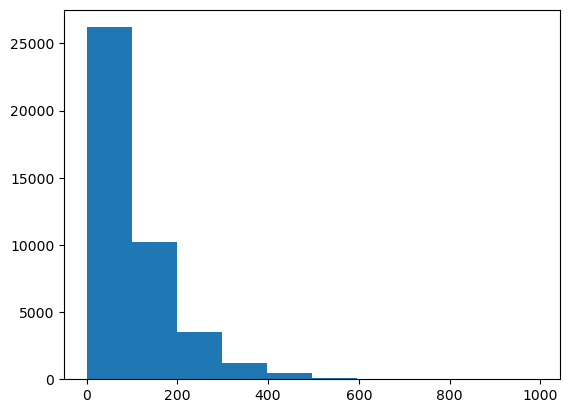

In [40]:
plt.hist(df["pm2.5"]);


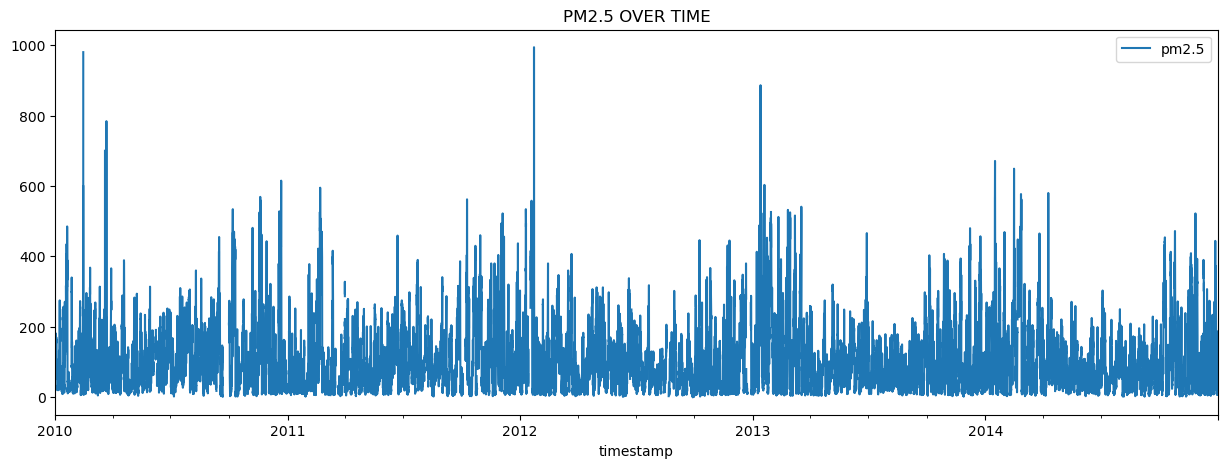

In [41]:
df.plot(
    x="timestamp",
    y="pm2.5",
    figsize=(15, 5),
    title = "PM2.5 OVER TIME"
);

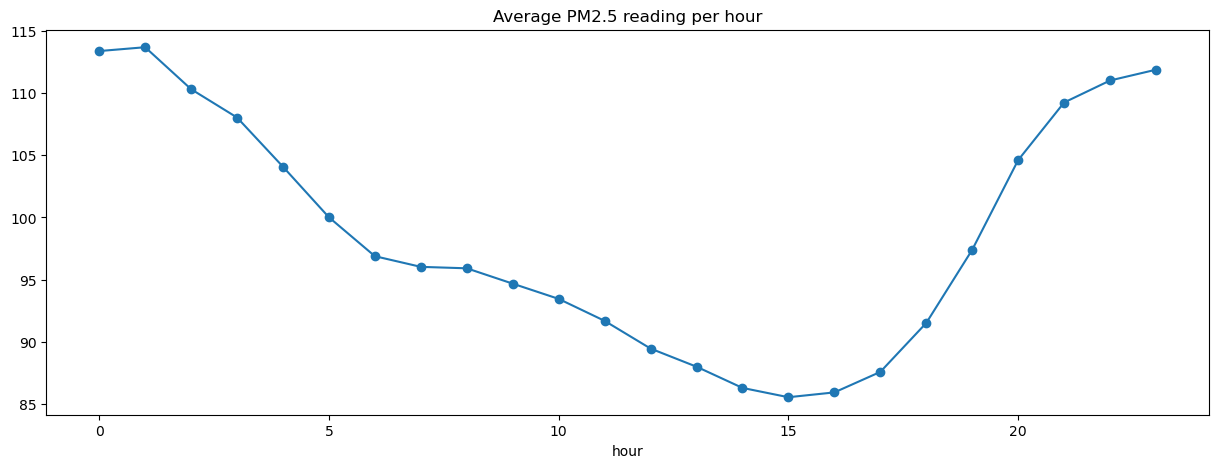

In [42]:
df.groupby("hour")["pm2.5"].mean().plot(
    figsize=(15, 5),
    marker="o",
    title="Average PM2.5 reading per hour"
);

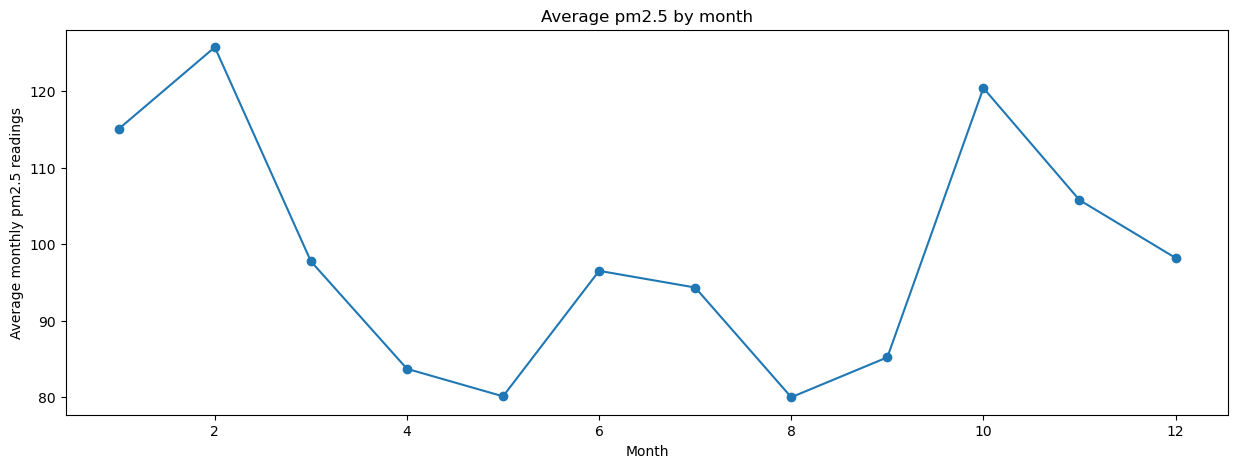

In [44]:
df.groupby("month")["pm2.5"].mean().plot(
    figsize=(15, 5),
    marker="o",
    xlabel="Month",
    ylabel = "Average monthly pm2.5 readings",
    title="Average pm2.5 by month"
);

In [50]:
yearly_monthly_pm25 = (
    df.groupby(["year", "month"])["pm2.5"]
    .mean()
    .unstack()
)

yearly_monthly_pm25

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2010,90.442573,97.233979,94.100141,80.029248,86.899593,109.003540,123.647849,97.602071,122.510684,118.982480,138.120482,97.333333
2011,44.891369,150.321429,57.918400,91.585821,65.321629,108.466948,107.572200,103.424561,95.272601,145.225649,109.632168,108.519515
2012,119.310448,83.997101,96.856757,87.518776,91.280753,96.596045,80.748547,80.865169,60.001401,94.839189,87.555874,109.197068
2013,193.273342,123.801788,123.064953,66.113287,85.125172,111.416435,68.983718,61.907483,90.747559,106.448509,91.045961,98.511050
2014,118.557666,174.617339,110.485868,95.232915,72.254717,59.082504,89.455902,62.942701,70.293706,140.555855,104.378187,78.648045


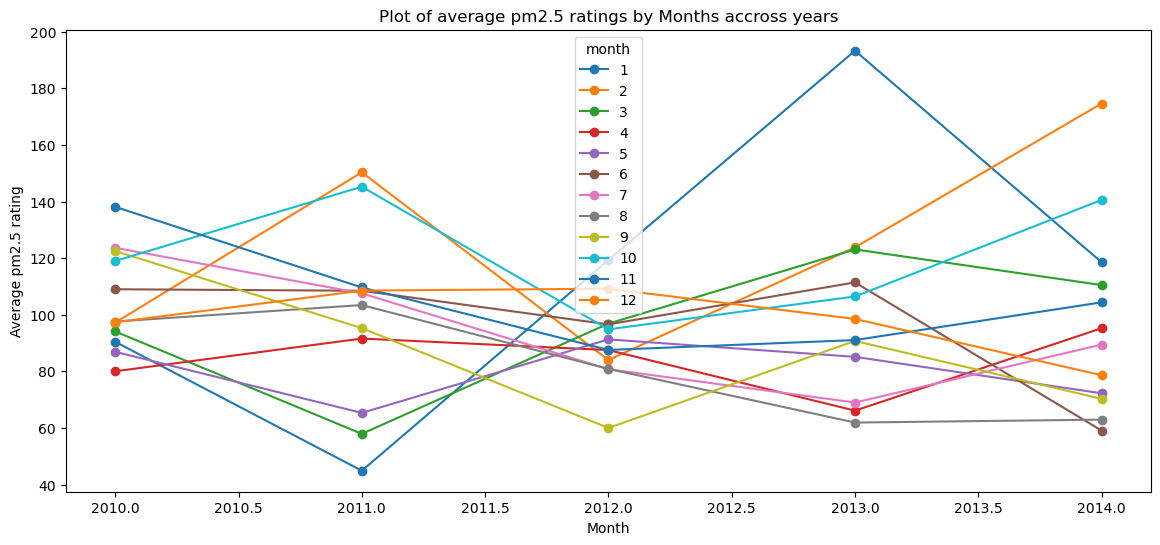

In [53]:
yearly_monthly_pm25.plot(
    figsize=(14, 6),
    marker="o",
    xlabel="Month",
    ylabel="Average pm2.5 rating",
    title="Plot of average pm2.5 ratings by Months accross years"
);

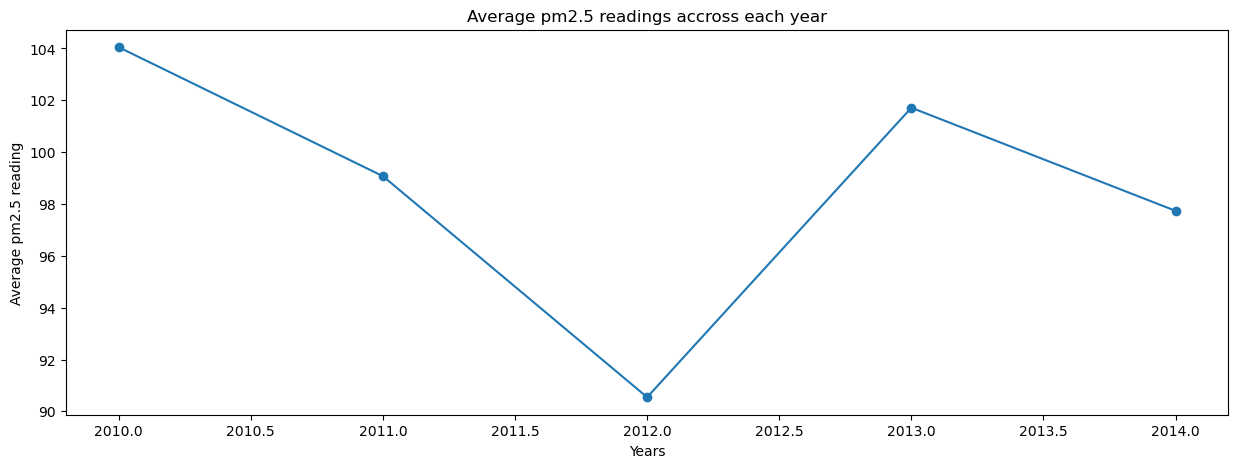

In [54]:
df.groupby("year")["pm2.5"].mean().plot(
    figsize=(15, 5),
    marker="o",
    title="Average pm2.5 readings accross each year",
    xlabel="Years",
    ylabel="Average pm2.5 reading"
);

In [61]:
df.groupby("year")["pm2.5"].mean()

year
2010    104.045730
2011     99.071340
2012     90.545871
2013    101.712376
2014     97.734557
Name: pm2.5, dtype: float64

In [72]:
df[["pm2.5", "DEWP", "TEMP", "PRES", "Iws", "Is", "Ir"]].corr()

,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
pm2.5,1.000000,0.171423,-0.090534,-0.047282,-0.247784,0.019266,-0.051369
DEWP,0.171423,1.000000,0.824633,-0.778346,-0.296399,-0.034410,0.125090
TEMP,-0.090534,0.824633,1.000000,-0.826690,-0.154623,-0.092601,0.049121
PRES,-0.047282,-0.778346,-0.826690,1.000000,0.185355,0.069028,-0.079843
Iws,-0.247784,-0.296399,-0.154623,0.185355,1.000000,0.021883,-0.010122
Is,0.019266,-0.034410,-0.092601,0.069028,0.021883,1.000000,-0.009548
Ir,-0.051369,0.125090,0.049121,-0.079843,-0.010122,-0.009548,1.000000


In [73]:
df.groupby("cbwd")["pm2.5"].agg(["mean", "median", "count"])

,mean,median,count
cbwd,,,
NE,90.177670,55.0,4756
NW,70.127633,31.0,13484
SE,110.821588,91.0,14573
cv,126.151945,98.0,8944
